# Skincare Recommendation System — Demo
This notebook imports the modular pipeline and runs demos + evaluation.
Make sure to run `build_modules.ipynb` first to create all `.py` files.

## Setup

In [1]:
!pip install chromadb google-genai

In [2]:
import sys
from google.colab import drive, userdata
from google import genai

# Mount Drive and add project to Python path
drive.mount('/content/drive')
sys.path.append('/content/drive/MyDrive/skincare_project')

# Initialize Gemini client
api_key = userdata.get('GEMINI_API_KEY')
client = genai.Client(api_key=api_key)
print("Setup complete.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Setup complete.


## Load Data & Build Vector Database

In [3]:
from data_loader import load_and_clean_data, build_vector_database

products_df, inci_df = load_and_clean_data()
product_collection, ingredient_collection = build_vector_database(products_df, inci_df)

Loaded 2418 products and 248 ingredients.
Indexed 2418 products and 248 ingredients.


## Test Agent 1: Skin Profile Agent

In [4]:
import json
from agents.skin_profile import skin_profile_agent

test_input = "I have oily acne-prone skin and I am allergic to fragrance. Looking for a full routine."
profile = skin_profile_agent(client, test_input)
print(json.dumps(profile, indent=2))

{
  "skin_type": "oily",
  "concerns": [
    "acne"
  ],
  "allergies": [
    "fragrance"
  ],
  "age": null,
  "current_products": null,
  "goals": null,
  "routine_request": "full routine"
}


## Test Agent 2: Product Retrieval Agent

In [5]:
from agents.retrieval import search_products

results = search_products(product_collection, "gentle cleanser for oily acne-prone skin", product_type="Cleanser")

for i in range(len(results['ids'][0])):
    meta = results['metadatas'][0][i]
    distance = results['distances'][0][i]
    print(f"{i+1}. {meta['name']}")
    print(f"   Brand: {meta['brand']} | Type: {meta['product_type']} | Price: {meta['price']}")
    print(f"   Relevance: {1 - distance:.3f}")
    print()

1. Make-Up Removing Cleansing Oil
   Brand: CAUDALIE | Type: Cleanser | Price: 28
   Relevance: 0.528

2. EradiKate® Daily Cleanser Acne Treatment
   Brand: KATE SOMERVILLE | Type: Cleanser | Price: 38
   Relevance: 0.528

3. Avène Cleanance Cleansing Gel 200ml
   Brand: Avène Cleanance | Type: Cleanser | Price: £12.00
   Relevance: 0.524

4. Acne Solutions Clarifying Lotion
   Brand: CLINIQUE | Type: Cleanser | Price: 17
   Relevance: 0.520

5. Cleanser
   Brand: EVE LOM | Type: Cleanser | Price: 80
   Relevance: 0.518



## Test Agent 3: Conflict Checker

In [6]:
from agents.conflict_checker import conflict_lookup, beneficial_lookup, rag_conflict_check

print(f"Conflict rules loaded for {len(conflict_lookup)} ingredients")
print(f"Beneficial pairs loaded for {len(beneficial_lookup)} ingredients")

# Example: check a list of ingredients from a routine
ingredients = ["niacinamide", "retinol", "ceramide", "squalane", "peptides"]

# Hardcoded rule check
for ing in ingredients:
    if ing in conflict_lookup:
        print(f"⚠ Hardcoded conflicts for {ing}: {conflict_lookup[ing]}")
    if ing in beneficial_lookup:
        print(f"✓ Beneficial pairs for {ing}: {beneficial_lookup[ing]}")

# RAG check for anything not covered by hardcoded rules
rag_results = rag_conflict_check(client, ingredient_collection, ingredients)
print(f"\nRAG-identified conflicts: {rag_results}")

Conflict rules loaded for 8 ingredients
Beneficial pairs loaded for 8 ingredients
⚠ Hardcoded conflicts for niacinamide: [{'conflicts_with': 'aha', 'reason': 'Can cause redness.'}, {'conflicts_with': 'bha', 'reason': 'Can cause redness.'}]
✓ Beneficial pairs for niacinamide: [{'pairs_with': 'retinol', 'benefit': 'Improves skin blemishes, diminishes ageing, and evens out skin tone.'}]
⚠ Hardcoded conflicts for retinol: [{'conflicts_with': 'vitamin c', 'reason': 'Cancel out effects.'}, {'conflicts_with': 'aha', 'reason': 'Cancel out effects and cause irritation.'}, {'conflicts_with': 'bha', 'reason': 'May cause breakouts, dry skin, and irritation.'}, {'conflicts_with': 'citric acid', 'reason': 'Excessive dryness, redness, sensitivity, or a rash.'}, {'conflicts_with': 'benzoyl peroxide', 'reason': 'Too harsh for skin and cancel out effects.'}]
✓ Beneficial pairs for retinol: [{'pairs_with': 'niacinamide', 'benefit': 'Improves skin blemishes, diminishes ageing, and evens out skin tone.'}, 

## Test Agent 4: Routine Builder

In [7]:
## Test Agent 4: Routine Builder
from agents.routine_builder import routine_builder_agent

sample_profile = {"skin_type": "oily", "concerns": ["acne"], "allergies": ["fragrance"],
                  "age": None, "goals": ["manage acne"], "routine_request": "full routine"}
sample_products = [
    {"name": "Gentle Cleanser", "brand": "BrandA", "product_type": "Cleanser",
     "ingredients": "water, glycerin, salicylic acid", "price": "15"},
    {"name": "Oil-Free Moisturizer", "brand": "BrandB", "product_type": "Moisturizer",
     "ingredients": "water, niacinamide, hyaluronic acid", "price": "20"}
]
sample_conflicts = {"conflicts": [], "allergy_flags": [], "beneficial": []}

routine = routine_builder_agent(client, sample_profile, sample_products, sample_conflicts)
print(json.dumps(routine, indent=2))

{
  "morning_routine": [
    {
      "step": 1,
      "product_type": "Cleanser",
      "product_name": "Gentle Cleanser",
      "brand": "BrandA",
      "why": "Contains salicylic acid to help exfoliate pores, reduce oil, and treat acne, suitable for oily and acne-prone skin without fragrance."
    },
    {
      "step": 2,
      "product_type": "Moisturizer",
      "product_name": "Oil-Free Moisturizer",
      "brand": "BrandB",
      "why": "An oil-free formula ideal for oily skin, containing niacinamide to help control oil and soothe blemishes, and hyaluronic acid for lightweight hydration without fragrance."
    }
  ],
  "evening_routine": [
    {
      "step": 1,
      "product_type": "Cleanser",
      "product_name": "Gentle Cleanser",
      "brand": "BrandA",
      "why": "Effectively cleanses away impurities, excess oil, and makeup while its salicylic acid content continues to target acne concerns overnight, suitable for oily and acne-prone skin without fragrance."
    },
    

## Full Pipeline


In [8]:
## Full Pipeline Test

from pipeline import full_pipeline

test_input = "I have oily acne-prone skin and I am allergic to fragrance. Looking for a full routine."
result = full_pipeline(client, product_collection, ingredient_collection, test_input)

print("=== PROFILE ===")
print(json.dumps(result["profile"], indent=2))

print(f"\n=== RETRIEVED {len(result['retrieved_products'])} PRODUCTS ===")
for p in result["retrieved_products"]:
    print(f"  - [{p['product_type']}] {p['name']} ({p['brand']})")

print(f"\n=== CONFLICT REPORT ===")
print(f"Conflicts: {len(result['conflict_report']['conflicts'])}")
for c in result["conflict_report"]["conflicts"]:
    print(f"  - {c['ingredient_a']} + {c['ingredient_b']}: {c['reason']}")
print(f"Allergy flags: {len(result['conflict_report']['allergy_flags'])}")
for a in result["conflict_report"]["allergy_flags"]:
    print(f"  - {a['product']}: contains {a['allergen']}")
print(f"Beneficial pairs: {len(result['conflict_report']['beneficial'])}")
for b in result["conflict_report"]["beneficial"]:
    print(f"  - {b['ingredient_a']} + {b['ingredient_b']}: {b['benefit']}")

print("\n=== ROUTINE ===")
print(json.dumps(result["routine"], indent=2))

Routine preference detected: both
=== PROFILE ===
{
  "skin_type": "oily",
  "concerns": [
    "acne"
  ],
  "allergies": [
    "fragrance"
  ],
  "age": null,
  "current_products": [],
  "goals": [],
  "routine_request": "full routine"
}

=== RETRIEVED 12 PRODUCTS ===
  - [Moisturizer] Face Hero (GO-TO)
  - [Moisturizer] Crème Ancienne® Soft Cream (FRESH)
  - [Moisturizer] Crème Ancienne® (FRESH)
  - [Cleanser] Avène Cleanance Cleansing Gel 200ml (Avène Cleanance)
  - [Cleanser] Make-Up Removing Cleansing Oil (CAUDALIE)
  - [Cleanser] EradiKate® Daily Cleanser Acne Treatment (KATE SOMERVILLE)
  - [Sun protect] Summer Duo (COOLA)
  - [Sun protect] Oil-Free Sun Guard Sunscreen Water Resistant SPF 45 (JACK BLACK)
  - [Sun protect] Sun Oil 15 SPF (MOROCCANOIL)
  - [Serum] Pai Skincare Instant Calm Redness Serum Sea Aster and Wild Oat 30ml (Pai Skincare)
  - [Serum] DECLÉOR Organic Aromessence Rose d'Orient Soothing Comfort Oil Serum (DECLÉOR Organic)
  - [Serum] La Roche-Posay Toleriane U

## Evaluation

In [9]:
# import pandas as pd
# from pipeline import full_pipeline
#
# test_cases = [
#     {
#         "id": "TC01",
#         "description": "Oily acne-prone skin, fragrance allergy",
#         "input": "I have oily acne-prone skin and I am allergic to fragrance. Looking for a full routine.",
#         "expected_conflict": False,
#         "expect_allergy_flag": True
#     },
#     {
#         "id": "TC02",
#         "description": "Conflict trigger: retinol and AHA combination",
#         "input": "I want to use a retinol serum and an AHA exfoliant together for anti-aging and smoother skin.",
#         "expected_conflict": True,
#         "expect_allergy_flag": False
#     },
#     {
#         "id": "TC03",
#         "description": "Dry sensitive skin, minimal routine",
#         "input": "I have very dry sensitive skin that gets red easily. I need a gentle cleanser and a heavy moisturizer.",
#         "expected_conflict": False,
#         "expect_allergy_flag": False
#     }
# ]
#
# eval_results = []
# for tc in test_cases:
#     print("Running: " + tc["id"] + " - " + tc["description"])
#     result = full_pipeline(client, product_collection, tc["input"])
#     conflict_detected = len(result["conflict_report"]["conflicts"]) > 0
#     allergy_flagged = len(result["conflict_report"]["allergy_flags"]) > 0
#     eval_results.append({
#         "test_id": tc["id"],
#         "description": tc["description"],
#         "conflict_detected": conflict_detected,
#         "expected_conflict": tc["expected_conflict"],
#         "conflict_correct": conflict_detected == tc["expected_conflict"],
#         "allergy_flagged": allergy_flagged,
#         "expected_allergy_flag": tc["expect_allergy_flag"],
#         "allergy_correct": allergy_flagged == tc["expect_allergy_flag"]
#     })
#     print()
#
# eval_df = pd.DataFrame(eval_results)
# print(eval_df[["test_id", "description", "conflict_correct", "allergy_correct"]])
# print("\nConflict detection accuracy: " + str(eval_df["conflict_correct"].mean()))
# print("Allergy detection accuracy: " + str(eval_df["allergy_correct"].mean()))

In [18]:
import pandas as pd
import time
import importlib
import pipeline
importlib.reload(pipeline)
from pipeline import full_pipeline

# 20 Test Cases grounded in the Skincare Knowledge Graph dataset
# expected_conflict: True if the input mentions a known conflicting ingredient pair
# expect_allergy_flag: True if the input mentions an allergy that should be detected

test_cases = [
    # Skin type variations (TC01-TC05)
    {
        "id": "TC01",
        "description": "Oily acne-prone skin, fragrance allergy",
        "input": "I have oily acne-prone skin and I am allergic to fragrance. Looking for a full routine.",
        "expected_conflict": False,
        "expect_allergy_flag": True
    },
    {
        "id": "TC02",
        "description": "Dry sensitive skin, minimal routine",
        "input": "I have very dry sensitive skin that gets red easily. I need a gentle cleanser and a heavy moisturizer.",
        "expected_conflict": False,
        "expect_allergy_flag": False
    },
    {
        "id": "TC03",
        "description": "Combination skin, anti-aging goals",
        "input": "I have combination skin and I am in my 30s. I want to start an anti-aging routine.",
        "expected_conflict": False,
        "expect_allergy_flag": False
    },
    {
        "id": "TC04",
        "description": "Normal skin, basic routine",
        "input": "I have normal skin with no major concerns. Just looking for a simple morning and evening routine.",
        "expected_conflict": False,
        "expect_allergy_flag": False
    },
    {
        "id": "TC05",
        "description": "Sensitive skin with redness",
        "input": "I have sensitive skin that gets red and irritated easily. I need very gentle fragrance-free products.",
        "expected_conflict": False,
        "expect_allergy_flag": True
    },
    # Known conflict triggers from Skincare Knowledge Graph (TC06-TC10)
    {
        "id": "TC06",
        "description": "Conflict: retinol + AHA",
        "input": "I want to use a retinol serum and an AHA exfoliant together for anti-aging and smoother skin.",
        "expected_conflict": True,
        "expect_allergy_flag": False
    },
    {
        "id": "TC07",
        "description": "Conflict: retinol + BHA",
        "input": "I want to combine retinol with a BHA toner to treat my acne and signs of aging.",
        "expected_conflict": True,
        "expect_allergy_flag": False
    },
    {
        "id": "TC08",
        "description": "Conflict: retinol + vitamin C",
        "input": "I want to use retinol and vitamin C serum together in my routine for anti-aging.",
        "expected_conflict": True,
        "expect_allergy_flag": False
    },
    {
        "id": "TC09",
        "description": "Conflict: retinol + benzoyl peroxide",
        "input": "I have acne and want to use retinol and benzoyl peroxide together in my routine.",
        "expected_conflict": True,
        "expect_allergy_flag": False
    },
    {
        "id": "TC10",
        "description": "Conflict: AHA + vitamin C",
        "input": "I want to layer an AHA toner with a vitamin C serum every morning for brighter skin.",
        "expected_conflict": True,
        "expect_allergy_flag": False
    },
    # Allergy cases (TC11-TC14)
    {
        "id": "TC11",
        "description": "Allergy to fragrance",
        "input": "I have oily skin and I am allergic to fragrance. Looking for a full routine.",
        "expected_conflict": False,
        "expect_allergy_flag": True
    },
    {
        "id": "TC12",
        "description": "Allergy to parabens",
        "input": "I have dry skin and I am allergic to parabens. I need a moisturizer and cleanser.",
        "expected_conflict": False,
        "expect_allergy_flag": True
    },
    {
        "id": "TC13",
        "description": "Multiple allergies: fragrance and sulfates",
        "input": "I have sensitive skin. I am allergic to fragrance and sulfates. Need a full gentle routine.",
        "expected_conflict": False,
        "expect_allergy_flag": True
    },
    {
        "id": "TC14",
        "description": "Allergy to alcohol",
        "input": "I have combination skin and I am allergic to alcohol. Please recommend products without alcohol.",
        "expected_conflict": False,
        "expect_allergy_flag": True
    },
    # Edge cases (TC15-TC20)
    {
        "id": "TC15",
        "description": "Conflict + allergy together",
        "input": "I have oily skin, I am allergic to fragrance, and I want to use retinol and AHA together for anti-aging.",
        "expected_conflict": True,
        "expect_allergy_flag": True
    },
    {
        "id": "TC16",
        "description": "Pregnancy-safe routine request",
        "input": "I am pregnant and need a pregnancy-safe skincare routine. I have normal skin with no allergies.",
        "expected_conflict": False,
        "expect_allergy_flag": False
    },
    {
        "id": "TC17",
        "description": "Teen with acne",
        "input": "I am 16 years old with oily acne-prone skin. I need a simple routine suitable for a teenager.",
        "expected_conflict": False,
        "expect_allergy_flag": False
    },
    {
        "id": "TC18",
        "description": "Existing routine, wants to add product",
        "input": "I already use a CeraVe cleanser and moisturizer daily. I want to add a vitamin C serum to my routine.",
        "expected_conflict": False,
        "expect_allergy_flag": False
    },
    {
        "id": "TC19",
        "description": "Hyperpigmentation concern",
        "input": "I have dark spots and hyperpigmentation on combination skin. What skincare routine should I follow?",
        "expected_conflict": False,
        "expect_allergy_flag": False
    },
    {
        "id": "TC20",
        "description": "Salicylic acid + benzoyl peroxide conflict",
        "input": "I want to use a salicylic acid cleanser with a benzoyl peroxide spot treatment for my acne.",
        "expected_conflict": True,
        "expect_allergy_flag": False
    },
]

# Run evaluation
eval_results = []
for tc in test_cases:
    print(f"Running {tc['id']}: {tc['description']}")
    result = full_pipeline(client, product_collection, ingredient_collection, tc["input"])
    conflict_detected = len(result["conflict_report"]["conflicts"]) > 0
    allergy_flagged = len(result["conflict_report"]["allergy_flags"]) > 0
    conflict_correct = conflict_detected == tc["expected_conflict"]
    allergy_correct = allergy_flagged == tc["expect_allergy_flag"]
    eval_results.append({
        "test_id": tc["id"],
        "description": tc["description"],
        "conflict_detected": conflict_detected,
        "expected_conflict": tc["expected_conflict"],
        "conflict_correct": conflict_correct,
        "allergy_flagged": allergy_flagged,
        "expected_allergy_flag": tc["expect_allergy_flag"],
        "allergy_correct": allergy_correct
    })
    print(f"  Conflict: detected={conflict_detected}, expected={tc['expected_conflict']} → {'✓' if conflict_correct else '✗'}")
    print(f"  Allergy:  flagged={allergy_flagged},   expected={tc['expect_allergy_flag']} → {'✓' if allergy_correct else '✗'}")
    print()
    time.sleep(10)

# Print summary table
eval_df = pd.DataFrame(eval_results)
print("=" * 70)
print(eval_df[["test_id", "description", "conflict_correct", "allergy_correct"]].to_string(index=False))
print()
print(f"Conflict detection accuracy: {eval_df['conflict_correct'].mean():.0%}")
print(f"Allergy detection accuracy:  {eval_df['allergy_correct'].mean():.0%}")

Running TC01: Oily acne-prone skin, fragrance allergy
Routine preference detected: both
  Conflict: detected=True, expected=False → ✗
  Allergy:  flagged=True,   expected=True → ✓

Running TC02: Dry sensitive skin, minimal routine
Routine preference detected: both
  Conflict: detected=True, expected=False → ✗
  Allergy:  flagged=False,   expected=False → ✓

Running TC03: Combination skin, anti-aging goals
Routine preference detected: both
  Conflict: detected=True, expected=False → ✗
  Allergy:  flagged=False,   expected=False → ✓

Running TC04: Normal skin, basic routine
Routine preference detected: both
  Conflict: detected=True, expected=False → ✗
  Allergy:  flagged=False,   expected=False → ✓

Running TC05: Sensitive skin with redness
Routine preference detected: both
  Conflict: detected=True, expected=False → ✗
  Allergy:  flagged=True,   expected=True → ✓

Running TC06: Conflict: retinol + AHA
Routine preference detected: both
  Conflict: detected=True, expected=True → ✓
  Alle

In [20]:
# Baseline Comparison: Raw Gemini

def baseline_gemini(client, user_input):
    """Send query directly to Gemini"""
    prompt = f"""You are a skincare expert. A user has described their skin concerns below.
Give them a personalized skincare routine recommendation.

User input: {user_input}

Provide a morning and evening routine with specific product type recommendations and explain why."""

    response = client.models.generate_content(model="gemini-2.5-flash", contents=prompt)
    return response.text

# Run baseline on 3 representative test cases
baseline_cases = [
    {"id": "TC01", "input": "I have oily acne-prone skin and I am allergic to fragrance. Looking for a full routine."},
    {"id": "TC06", "input": "I want to use a retinol serum and an AHA exfoliant together for anti-aging and smoother skin."},
    {"id": "TC13", "input": "I have sensitive skin. I am allergic to fragrance and sulfates. Need a full gentle routine."},
]

print()
print("BASELINE vs PIPELINE COMPARISON")
print()

for tc in baseline_cases:
    print(f"\n── {tc['id']} ──")
    print(f"Input: {tc['input']}\n")

    # Baseline: raw Gemini, no RAG
    print("BASELINE (raw Gemini, no RAG, no agents):")
    baseline_response = baseline_gemini(client, tc["input"])
    print(baseline_response[:600])
    print("...")

    # Pipeline: full RAG system
    print("\nPIPELINE (RAG + 4 agents):")
    pipeline_result = full_pipeline(client, product_collection, ingredient_collection, tc["input"])
    print(f"  Skin profile extracted: {pipeline_result['profile']}")
    print(f"  Products retrieved: {len(pipeline_result['retrieved_products'])} real products from database")
    print(f"  Conflicts detected: {len(pipeline_result['conflict_report']['conflicts'])}")
    print(f"  Allergy flags: {len(pipeline_result['conflict_report']['allergy_flags'])}")
    print(f"  Routine steps (AM): {len(pipeline_result['routine'].get('morning_routine', []))}")
    print(f"  Routine steps (PM): {len(pipeline_result['routine'].get('evening_routine', []))}")
    print()


BASELINE vs PIPELINE COMPARISON


── TC01 ──
Input: I have oily acne-prone skin and I am allergic to fragrance. Looking for a full routine.

BASELINE (raw Gemini, no RAG, no agents):
Hello there! I understand how frustrating it can be to manage oily, acne-prone skin, especially when you have the added challenge of a fragrance allergy. It's smart to seek out a tailored routine, as using the wrong products can often worsen these concerns.

As a skincare expert, I've designed a personalized, fragrance-free routine focusing on gentle yet effective ingredients to help control oil, treat breakouts, and maintain a healthy skin barrier.

**Core Principles for Your Skin Type:**

1.  **Strictly Fragrance-Free:** This is non-negotiable. Always look for labels that explicitly state "f
...

PIPELINE (RAG + 4 agents):
Routine preference detected: both
  Skin profile extracted: {'skin_type': 'oily', 'concerns': ['acne'], 'allergies': ['fragrance'], 'age': None, 'current_products': [], 'goals': ['red

# Updated Baseline vs Pipeline

In [22]:
def score_response(response_text=None, pipeline_result=None, test_case=None):
    """Score a response on key dimensions (1 point each)."""
    scores = {}

    if response_text:  # baseline scoring
        text = response_text.lower()
        scores["mentions_skin_type"] = 1 if any(k in text for k in ["oily", "dry", "sensitive", "combination"]) else 0
        scores["mentions_allergy"] = 1 if any(k in text for k in (test_case.get("allergies", []))) else 0
        scores["conflict_awareness"] = 1 if any(k in text for k in ["avoid", "don't use", "not together", "conflict"]) else 0
        scores["has_am_pm"] = 1 if ("morning" in text and "evening" in text) else 0
        scores["specific_products"] = 0  # baseline never returns real products
    else:  # pipeline scoring
        scores["mentions_skin_type"] = 1 if pipeline_result["profile"].get("skin_type") else 0
        scores["mentions_allergy"] = 1 if pipeline_result["conflict_report"]["allergy_flags"] else 0
        scores["conflict_awareness"] = 1 if pipeline_result["conflict_report"]["conflicts"] else 0
        scores["has_am_pm"] = 1 if (pipeline_result["routine"].get("morning_routine") and
                                     pipeline_result["routine"].get("evening_routine")) else 0
        scores["specific_products"] = 1  # pipeline always retrieves real products

    scores["total"] = sum(scores.values())
    return scores

def baseline_gemini(client, user_input):
    """Send query directly to Gemini with no RAG, no agents, no product database."""
    prompt = f"""You are a skincare expert. Give this user a personalized morning and evening skincare routine with specific product recommendations and explain why each is suitable.

User input: {user_input}"""
    response = client.models.generate_content(model="gemini-2.5-flash", contents=prompt)
    return response.text

baseline_cases = [
    {"id": "TC01", "input": "I have oily acne-prone skin and I am allergic to fragrance. Looking for a full routine.", "allergies": ["fragrance"]},
    {"id": "TC06", "input": "I want to use a retinol serum and an AHA exfoliant together for anti-aging and smoother skin.", "allergies": []},
    {"id": "TC13", "input": "I have sensitive skin. I am allergic to fragrance and sulfates. Need a full gentle routine.", "allergies": ["fragrance", "sulfates"]},
    {"id": "TC14", "input": "I want to use vitamin C and niacinamide together. I have dry skin.", "allergies": []},
    {"id": "TC15", "input": "What should I put on my face before bed? I have combination skin.", "allergies": []},
    {"id": "TC16", "input": "I have normal skin but I am allergic to retinol and benzoyl peroxide.", "allergies": ["retinol", "benzoyl peroxide"]},
]

print("BASELINE vs PIPELINE COMPARISON\n")
results_summary = []

for tc in baseline_cases:
    print(f"\n{'='*60}")
    print(f"{tc['id']}: {tc['input']}")
    print(f"{'='*60}")

    # Baseline
    print("\nBASELINE (raw Gemini, no RAG, no agents):")
    baseline_response = baseline_gemini(client, tc["input"])
    print(baseline_response)
    baseline_scores = score_response(response_text=baseline_response, test_case=tc)
    print(f"\nBaseline scores: {baseline_scores}")

    # Pipeline
    print("\nPIPELINE (RAG + 4 agents):")
    pipeline_result = full_pipeline(client, product_collection, ingredient_collection, tc["input"])
    print(f"  Routine preference: {pipeline_result['routine_preference']}")
    print(f"  Products retrieved: {len(pipeline_result['retrieved_products'])}")
    print(f"  Conflicts detected: {len(pipeline_result['conflict_report']['conflicts'])}")
    print(f"  Allergy flags: {len(pipeline_result['conflict_report']['allergy_flags'])}")

    # Print full morning routine
    print("\n  MORNING ROUTINE:")
    for step in pipeline_result['routine'].get('morning_routine', []):
        print(f"    Step {step.get('step', '')}: {step.get('product_name', '')} by {step.get('brand', '')}")
        print(f"    Why: {step.get('why', '')}")

    # Print full evening routine
    print("\n  EVENING ROUTINE:")
    for step in pipeline_result['routine'].get('evening_routine', []):
        print(f"    Step {step.get('step', '')}: {step.get('product_name', '')} by {step.get('brand', '')}")
        print(f"    Why: {step.get('why', '')}")

    # Print warnings if any
    if pipeline_result['routine'].get('warnings'):
        print("\n  WARNINGS:")
        for w in pipeline_result['routine'].get('warnings', []):
            print(f"    - {w}")

    pipeline_scores = score_response(pipeline_result=pipeline_result, test_case=tc)
    print(f"\nPipeline scores: {pipeline_scores}")

    results_summary.append({
        "id": tc["id"],
        "baseline_total": baseline_scores["total"],
        "pipeline_total": pipeline_scores["total"],
        "winner": "pipeline" if pipeline_scores["total"] > baseline_scores["total"] else "tie/baseline"
    })

# Summary table
print(f"\n{'='*60}\nSUMMARY\n{'='*60}")
print(f"{'ID':<8} {'Baseline':>10} {'Pipeline':>10} {'Winner':>12}")
print("-" * 44)
for r in results_summary:
    print(f"{r['id']:<8} {r['baseline_total']:>10} {r['pipeline_total']:>10} {r['winner']:>12}")

pipeline_wins = sum(1 for r in results_summary if r["winner"] == "pipeline")
print(f"\nPipeline outperformed baseline on {pipeline_wins}/{len(results_summary)} test cases")

BASELINE vs PIPELINE COMPARISON


TC01: I have oily acne-prone skin and I am allergic to fragrance. Looking for a full routine.

BASELINE (raw Gemini, no RAG, no agents):
Hello there! As a skincare expert, I understand the challenges of managing oily, acne-prone, and fragrance-allergic skin. It requires a strategic yet gentle approach to balance oil production, prevent breakouts, and soothe any irritation, all while avoiding common sensitizers.

The key principles for your skin will be:
1.  **Gentle Cleansing:** Avoid stripping the skin, which can trigger more oil production.
2.  **Targeted Exfoliation:** Primarily Salicylic Acid (BHA) to penetrate oil and clear pores.
3.  **Acne Treatment:** Ingredients like Benzoyl Peroxide or Adapalene (a retinoid) to address active breakouts and prevent new ones.
4.  **Lightweight Hydration:** Don't skip moisturizer! Dehydrated skin can compensate by producing more oil.
5.  **Sun Protection:** Crucial, especially when using active ingredients that 

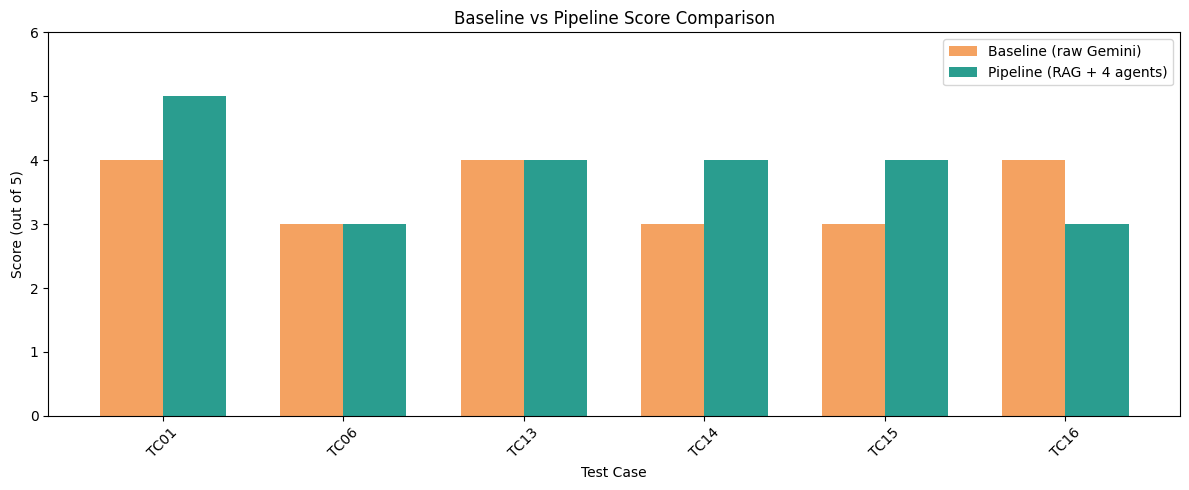

Average baseline score: 3.50/5
Average pipeline score: 3.83/5
Pipeline outperformed baseline on 3/6 test cases


In [23]:
import matplotlib.pyplot as plt
import numpy as np

ids = [r["id"] for r in results_summary]
baseline_scores = [r["baseline_total"] for r in results_summary]
pipeline_scores = [r["pipeline_total"] for r in results_summary]

x = np.arange(len(ids))
width = 0.35

fig, ax = plt.subplots(figsize=(12, 5))

ax.bar(x - width/2, baseline_scores, width, label="Baseline (raw Gemini)", color="#f4a261")
ax.bar(x + width/2, pipeline_scores, width, label="Pipeline (RAG + 4 agents)", color="#2a9d8f")

ax.set_xlabel("Test Case")
ax.set_ylabel("Score (out of 5)")
ax.set_title("Baseline vs Pipeline Score Comparison")
ax.set_xticks(x)
ax.set_xticklabels(ids, rotation=45)
ax.set_ylim(0, 6)
ax.legend()

plt.tight_layout()
plt.savefig("baseline_vs_pipeline.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"Average baseline score: {np.mean(baseline_scores):.2f}/5")
print(f"Average pipeline score: {np.mean(pipeline_scores):.2f}/5")
print(f"Pipeline outperformed baseline on {pipeline_wins}/{len(results_summary)} test cases")